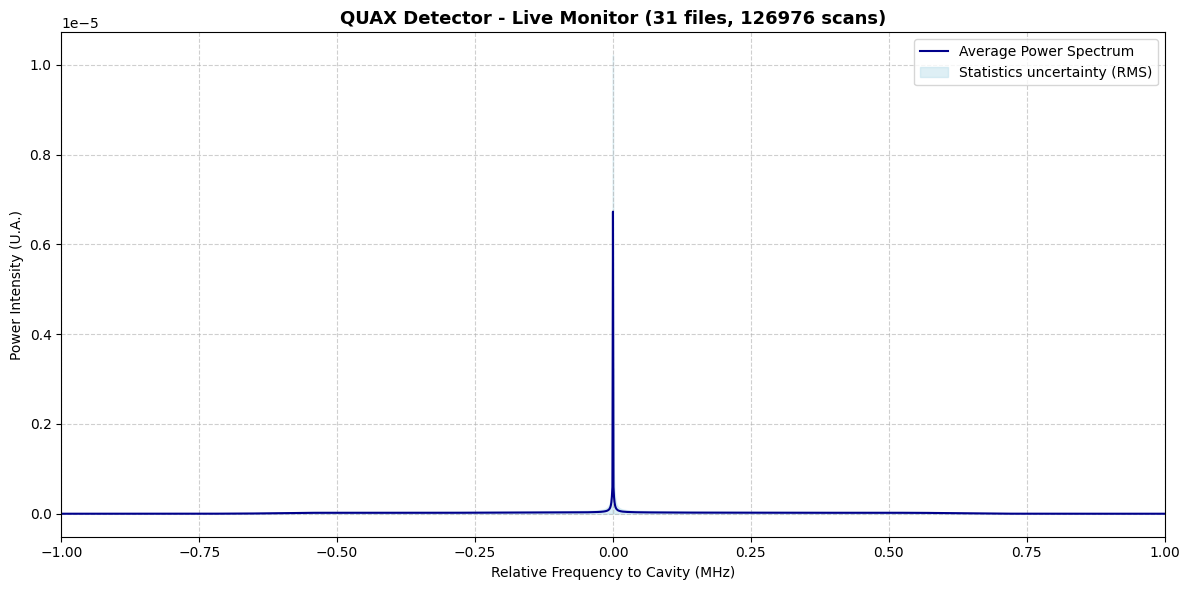

[INFO] Processing complete: 31 files, 126976 total scans.


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from confluent_kafka import Consumer
from IPython.display import clear_output

# CRITICAL: Updated to your VM2 CloudVeneto IP
KAFKA_BOOTSTRAP_SERVERS = '10.67.22.212:9092'  
RESULTS_TOPIC = 'topic_results'

print(f"[INFO] Connecting to Kafka broker at {KAFKA_BOOTSTRAP_SERVERS}...")

# Use the C-compiled Kafka Consumer
consumer = Consumer({
    'bootstrap.servers': KAFKA_BOOTSTRAP_SERVERS,
    'group.id': 'quax-live-visualizer',
    'auto.offset.reset': 'latest'  # Only listen for new results arriving right now
})
consumer.subscribe([RESULTS_TOPIC])

print(f"[INFO] Listening to '{RESULTS_TOPIC}' for live visualization. Start your producer!")

try:
    while True:
        # Poll Kafka for new messages every 1 second
        msg = consumer.poll(1.0)
        
        if msg is None:
            continue
        if msg.error():
            print(f"[ERROR] {msg.error()}")
            continue

        # Decode the JSON payload
        payload = json.loads(msg.value().decode('utf-8'))

        # Shift frequencies and power to center the spectrum
        freqs_shift = np.fft.fftshift(np.array(payload["frequencies"])) / 1e6
        mean_shift  = np.fft.fftshift(np.array(payload["averaged_power_spectrum"]))
        std_shift   = np.fft.fftshift(np.array(payload["std_power_spectrum"]))

        # Live update the plot
        clear_output(wait=True)
        plt.figure(figsize=(12, 6))
        
        # Plot Mean and fill Standard Deviation
        plt.plot(freqs_shift, mean_shift, color='darkblue', lw=1.5, label='Average Power Spectrum')
        plt.fill_between(freqs_shift, mean_shift - std_shift, mean_shift + std_shift,
                          color='lightblue', alpha=0.4, label='Statistics uncertainty (RMS)')
        
        # Dynamic Titles and Labels
        plt.title(f'QUAX Detector - Live Monitor '
                  f'({payload["n_files_processed"]} files, {payload["n_scans_total"]} scans)',
                  fontsize=13, fontweight='bold')
        plt.xlabel('Relative Frequency to Cavity (MHz)')
        plt.ylabel('Power Intensity (U.A.)')
        plt.xlim(-1.0, 1.0)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        # Gracefully close the loop if this is the last file
        if payload.get("is_final", False):
            print(f"[INFO] Processing complete: {payload['n_files_processed']} files, "
                  f"{payload['n_scans_total']} total scans.")
            break

except KeyboardInterrupt:
    print("\n[INFO] Live visualization manually stopped.")
finally:
    consumer.close()